### Authors

- Anna Beketova
- Shatu Ahmed

Target repository: [week2](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/Embedding/week2)

# Embedding using Convolutional Layers

### Introduction

Continuing on the foundation of the previous week's assignment, this week's objective delves deeper into leveraging computational techniques to create a protein embedding using Kidera factors, which are numerical representations of amino acid properties. The main goal remains the same, which is to encode protein sequences into a format that retains biologically relevant information while reducing data complexity. This week focuces on the methods Convolutional neural networks (CNNs) and sequence padding. The aim is to enhance the model's ability to process protein data efficiently while minimizing information loss during embedding and training.

### Implementation

Changes were made to the preprocessing of the data. Instead of using the protein family names as identifiers, the bin leaves were used instead, as they are unique and much shorter.

The bins were extracted from the CSV file: "mapmanreferencebins_simpl.tsv," which was generated using the provided code in the gitlab repository. The result was then saved as "NEWHELP_labeled_sequences.csv".

In [ ]:
import pandas as pd
from Bio import SeqIO
import csv

#read data
data = pd.read_csv("mapmanreferencebins_simpl.tsv", sep="\t")

bincode_dict = {} # dictionary to store all identifiers of each family


for index, row in data.iterrows():
    bincode = row['BINCODE'].strip("'")
    protein_id = row['IDENTIFIER'].strip("'").lower()
    if(protein_id):
        if(bincode not in bincode_dict):
            bincode_dict[bincode] = []
        bincode_dict[bincode].append(protein_id)


print(sum(len(v) for v in bincode_dict.values()))

proteins = "protein.fa"
protein_dict = {}

for record in SeqIO.parse(proteins, "fasta"):
    uniprot_id = record.id.split("|")[-1].lower()
    sequence = str(record.seq)
    protein_dict[uniprot_id] = sequence

grouped_dict = {}
for bincode, protein_ids in bincode_dict.items():
    sequences = [protein_dict[p] for p in protein_ids if p in protein_dict]
    if sequences:
        grouped_dict[bincode] = sequences
    else:
        grouped_dict[bincode] = []

result = "labeled_sequences.csv"
with open(result, "w") as newfile:
    newfile.write("bincode,sequence\n")
    for bincode, sequences in grouped_dict.items():
        for seq in sequences:
            newfile.write(f"{bincode}, {seq}\n")


cleaned_rows = []

with open("labeled_sequences.csv", "r") as infile:
    reader = csv.reader(infile)
    for row in reader:
        if len(row) > 2:
            bincode = row[0]
            sequence = ''.join(row[1:]).replace('"', '').replace("'", "") # Merge falsely added columns and clean quotes
            cleaned_rows.append([bincode, sequence])
        elif len(row) == 2:
            cleaned_rows.append(row)
        else:
            print(f"Skipping malformed row: {row}")


with open("NEWHELP_labeled_sequences.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_rows)

print("done")

### Embedding step

We encoded protein sequences using Kidera factors, which represent amino acids as vectors of 10 numerical features. Each protein sequence was transformed into a matrix, where rows correspond to amino acids and columns represent their respective Kidera factors. Previously, we took the mean of each kidera factor; this led to a lot of informational loss. Hence, a 3D array was used to handle the information. To handle varying sequence lengths, we applied padding to ensure uniform dimensions. The sequences were given a fixed size of 256 (and 409), enabling the data to be input into a convolutional neural network (CNN) for further processing. The CNN Models require the Input form to be an array with the dimensions [batch_size, num_features, sequence_length], further highlighting the use of a 3D array to embed our factors.
Additionally we changed our kidera factors to the provided one in the gitlap repository.
This was done via the file [emb.py](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/blob/Embedding/week2/methods/emb.py) which can be found the in the materials directory of week2



In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Read the labeled data from CSV file
labled = pd.read_csv("NEWHELP_labeled_sequences.csv")

# Kidera factors dictionary (as per your input)
kidera_factors = {
    'A': [-1.56, -1.67, -0.97, -0.27, -0.93, -0.78, -0.2, -0.08, 0.21, -0.48],
    'C': [0.12, -0.89, 0.45, -1.05, -0.71, 2.41, 1.52, -0.69, 1.13, 1.1],
    'D': [0.58, -0.22, -1.58, 0.81, -0.92, 0.15, -1.52, 0.47, 0.76, 0.7],
    'E': [-1.45, 0.19, -1.61, 1.17, -1.31, 0.4, 0.04, 0.38, -0.35, -0.12],
    'F': [-0.21, 0.98, -0.36, -1.43, 0.22, -0.81, 0.67, 1.1, 1.71, -0.44],
    'G': [1.46, -1.96, -0.23, -0.16, 0.1, -0.11, 1.32, 2.36, -1.66, 0.46],
    'H': [-0.41, 0.52, -0.28, 0.28, 1.61, 1.01, -1.85, 0.47, 1.13, 1.63],
    'I': [-0.73, -0.16, 1.79, -0.77, -0.54, 0.03, -0.83, 0.51, 0.66, -1.78],
    'K': [-0.34, 0.82, -0.23, 1.7, 1.54, -1.62, 1.15, -0.08, -0.48, 0.6],
    'L': [-1.04, 0, -0.24, -1.1, -0.55, -2.05, 0.96, -0.76, 0.45, 0.93],
    'M': [-1.4, 0.18, -0.42, -0.73, 2, 1.52, 0.26, 1.23, -1.27, 0.27],
    'N': [1.14, -0.07, -0.12, 0.81, 0.18, 0.37, -0.09, -2.3, 1.1, -1.73],
    'P': [2.06, 0.24, -1.15, -0.75, 0.88, -0.45, 0.84, -0.71, 0.74, -0.28],
    'Q': [-0.47, 1.27, 0.07, 1.1, 1.1, 0.59, 0.92, -1.15, -0.03, -2.33],
    'R': [0.22, -0.7, 1.37, 1.87, -1.7, 0.46, 0.84, -0.39, 0.23, 0.93],
    'S': [0.81, 1.27, 0.16, 0.42, -0.21, -0.43, 0.92, -1.15, -0.97, -0.23],
    'T': [0.26, -1.08, 1.21, 0.63, -0.1, 0.21, 0.24, -1.15, -0.56, 0.19],
    'V': [-0.74, -0.7, 2.04, -0.4, 0.5, -0.81, -1.07, 0.06, -2.3, -0.6],
    'W': [0.3, -0.71, -0.72, -1.57, -1.16, 0.57, -0.48, -0.4, -0.05, 0.53],
    'Y': [1.38, 2.1, 0.8, -0.56, 0, -0.68, -0.31, 1.03, -0.6, 0.53]
}

default_kidera_vector = [0.0] * 10  # Default vector for unknown amino acids

def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):

    #Converts a sequence of amino acids into an array of Kidera factor embeddings.

    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence])

def process_sequences(sequences, max_length, kidera_dict, default_vector):

   # Process the list of sequences, encode them with Kidera factors, and pad them to a uniform length.

    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in sequences]
    return pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

sequences = labled['sequence'].tolist()  # Convert the 'sequence' column to a list

# Process the sequences and pad them
max_length = 409  # 256 Maximum length dervided from the average
kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

#Display processed sequences
#print(kidera_encoded_sequences[:2])
#print(labled.head())



Afterwards the bins  were extracted to be used as labels in our machine learning model:

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv('NEWHELP_labeled_sequences.csv')

bincode = labled['bincode'].tolist()

label_encoder = LabelEncoder()
bincode_encoded = label_encoder.fit_transform(bincode)

print(bincode_encoded[:5]) #test

### Implementing a multi layered Convolutional Model


We tested our Model for batch sizes 32 and 62 as well as with 50 and 100 epoches:

This was done with the file [cnn_model.py](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/blob/Embedding/week2/methods/cnn_model.py) whcih is also included in the methods directory.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef

'''
Simulate the dataset
kidera_encoded_sequences = np.random.rand(41669, 256, 10)
labels = np.random.randint(0, 10, size=(41669,))  # Simulated labels (10 classes)
'''

# Convert to PyTorch tensors
kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.long)

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)

# Split the dataset into training and validation sets
dataset = TensorDataset(kidera_encoded_sequences_tensor, labels_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#DataLoaders for batching
batch_size = 32 #adjust as necessary for different batches
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


#print(f"Max label: {labels_tensor.max()}, Min label: {labels_tensor.min()}")

num_classes = len(np.unique(labels_tensor))  #number of unique labels


# CNN model
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)



    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 256)  # Simulate a single input
        dummy_output = self.conv1(dummy_input)
        dummy_output = self.conv2(dummy_output)
        dummy_output = self.conv3(dummy_output)
        dummy_output = self.conv4(dummy_output)
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.fc(x)
        return x

# Initialize the model, loss function, and optimizer
model = ConvolutionalNetwork()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 100
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()  # Set model to training mode
    total_train_loss = 0.0

    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad()  # Clear gradients
        outputs = model(batch_data)  # Forward pass
        loss = loss_fn(outputs, batch_labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_train_loss += loss.item()

# Evaluate on validation
    model.eval()  # Set model to evaluation mode
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

# Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Get true labels and predictions
y_test = []
y_pred = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch
        outputs = model(batch_data)
        _, predicted = torch.max(outputs, dim=1)  # Get class index with max probability
        y_test.extend(batch_labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_test = np.array(y_test)
y_pred = np.array(y_pred)

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", mcc)

print("Unique classes in y_test:", len(set(y_test)))
print("Unique classes in y_pred:", len(set(y_pred)))


# Visualization
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()



Model with SGD optimizer, ReLU activation function, Dropout and Learning Rate scheduler:

New padding length was used (average sequence length), in order to try to fix the issue with class imbalance, and to keep as much protein information as possible.

SGD optimizer was tried instead of Adam to reach better generalisation.

Relu activation function was used to capture non linear complex patterns, crucial for classification or feature extraction.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef, precision_score, recall_score, f1_score
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler


scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.3, total_iters=10)


# Convert to PyTorch tensors
kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.long)

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)

# Split the dataset into training and validation sets
dataset = TensorDataset(kidera_encoded_sequences_tensor, labels_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


#print(f"Max label: {labels_tensor.max()}, Min label: {labels_tensor.min()}")

num_classes = len(np.unique(labels_tensor))  # Determine number of unique labels


class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)

        # Dropout layers
        self.dropout3 = nn.Dropout(p=0.2)
        self.dropout4 = nn.Dropout(p=0.2)
        self.fc_dropout = nn.Dropout(p=0.5)

        # Calculate the flattened output size for the fully connected layer
        self._calculate_conv_output_size()

        # Fully connected layer
        self.fc = nn.Linear(self.conv_output_size, num_classes)

    def _calculate_conv_output_size(self):
        # Simulate input to calculate the size of the flattened feature map
        dummy_input = torch.rand(1, 10, 409)  # [batch_size, in_channels, sequence_length]
        dummy_output = self.conv1(dummy_input)
        dummy_output = self.conv2(dummy_output)
        dummy_output = self.conv3(dummy_output)
        dummy_output = self.conv4(dummy_output)
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)  # Channels * Length

    def forward(self, x):
        # Convolutional layers with activation functions
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.dropout3(torch.relu(self.conv3(x)))  #  dropout after conv3
        x = self.dropout4(torch.relu(self.conv4(x)))  #  dropout after conv4

        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)

        # Apply final dropout before fully connected layer
        x = self.fc_dropout(x)
        x = self.fc(x)
        return x


# Initialize the model, loss function, and optimizer
model = ConvolutionalNetwork()
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)  # Adjusting learning rate and optimizer algorithm
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True) # schedule to avoid validation loss plateau

# Training loop
epochs = 50
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()  # Set model to training mode
    total_train_loss = 0.0

    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad()  # Clear gradients
        outputs = model(batch_data)  # Forward pass
        loss = loss_fn(outputs, batch_labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_train_loss += loss.item()

    # Evaluate on validation set
    model.eval()  # Set model to evaluation mode
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

    # Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Get true labels and predictions
y_test = []
y_pred = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch  # Extract data and labels from batch
        outputs = model(batch_data)  # Get model predictions
        _, predicted = torch.max(outputs, dim=1)  # Get class index with max probability
        y_test.extend(batch_labels.cpu().numpy())  # Append true labels
        y_pred.extend(predicted.cpu().numpy())  # Append predicted labels

# Convert lists to NumPy arrays
y_test = np.array(y_test)
y_pred = np.array(y_pred)

# Compute Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", mcc)

# Check unique classes
print("Unique classes in y_test:", len(set(y_test)))
print("Unique classes in y_pred:", len(set(y_pred)))

# Classification report
#print("Classification Report:")
#print(classification_report(y_test, y_pred))

# Individual metrics
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted',  zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted',  zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



# Visualization of training and validation loss
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

additional pooling to reduce overfitting: done by adding the line

```
        dummy_output = self.pool1(dummy_output)  # Apply pooling
```
after each convolution layder in the "_calculate_conv_output_size" method and adding

```
        x = self.pool1(x)  # Apply pooling after first convolution

```
in the method "forward()"




#### Sequence length = 256:

Optimizer: Adaptive Moment Estimation with learning rate 0.001

##### 50 epochs and 32 batches:


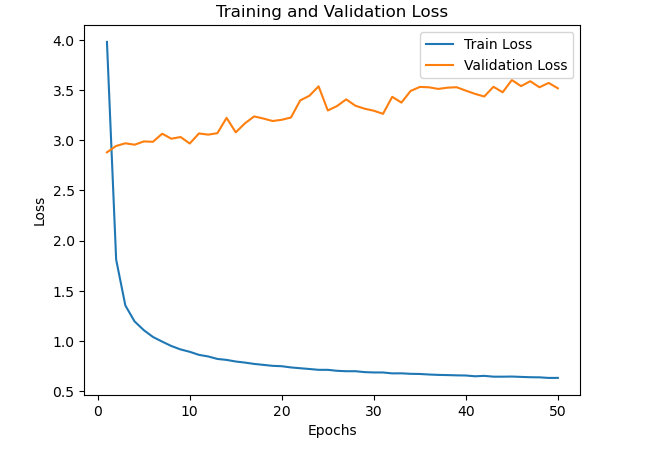

Matthews Correlation Coefficient: 0.5118159353202223

Unique classes in y_test: 2395

Unique classes in y_pred: 1527


![](50epochs.JPG)

##### 100 epochs and 32 batches:





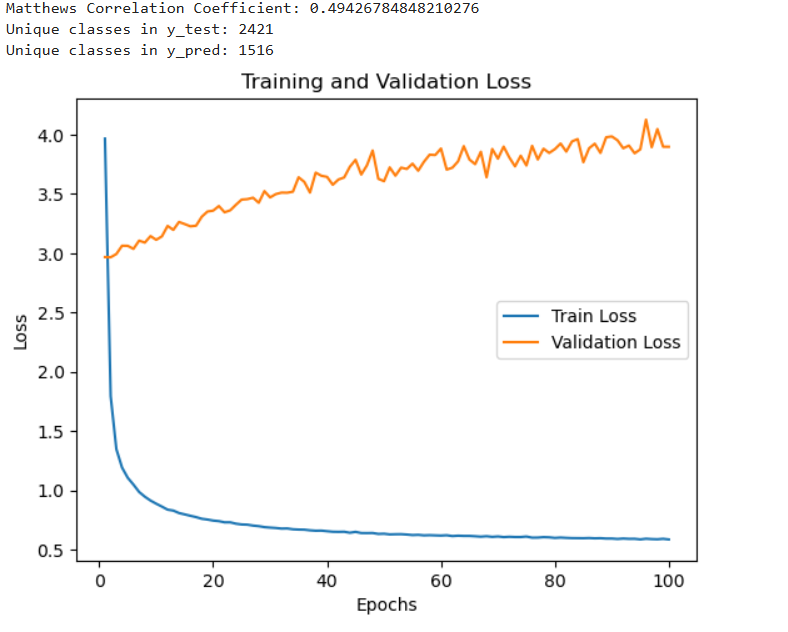

##### 100 epochs and 64 batches:


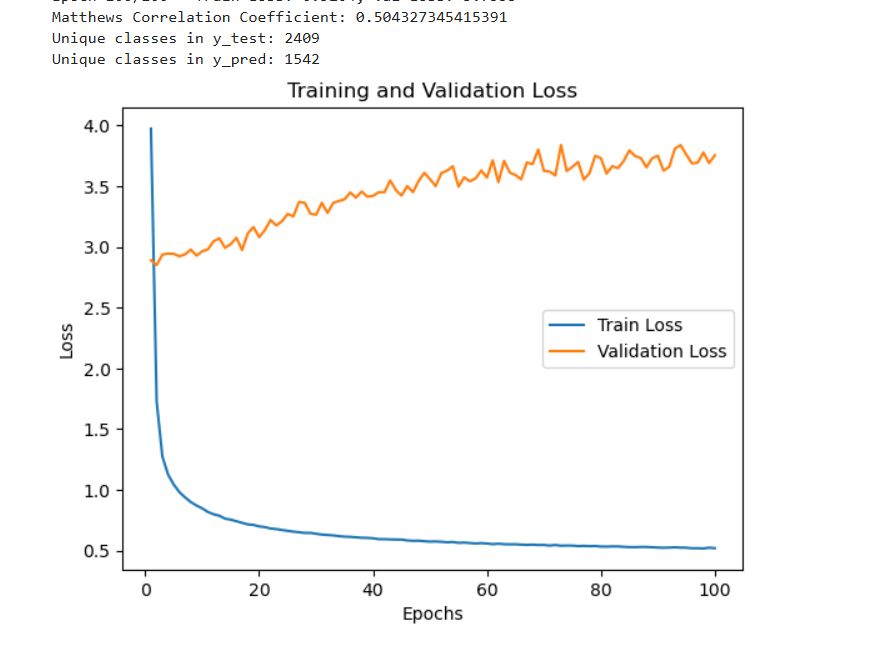

#### Sequence length = 409:

 Batch size: 32

 50 epochs

 Optimizer: Stochastic Gradient Descent with Learning Rate = 0.01

 Activation function: ReLU



 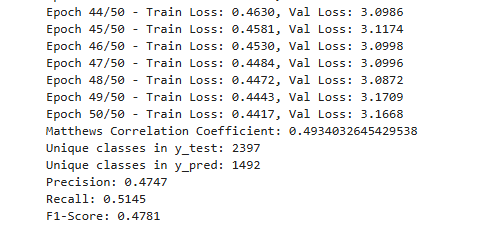







![](sgd50.JPG)

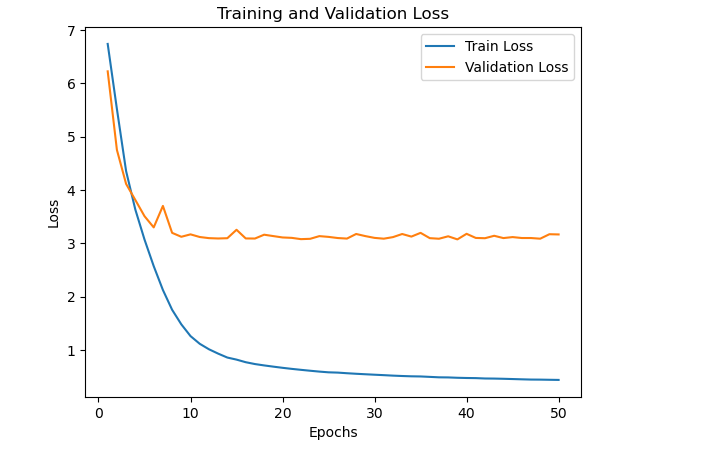

![](sgd50plot.png)

Batch size: 32

 50 epochs

 Optimizer: Stochastic Gradient Descent with Learning Rate = 0.01

 Weight decay: 1e-4

 Dropout

 Learning rate scheduler

 Activation function: ReLU


 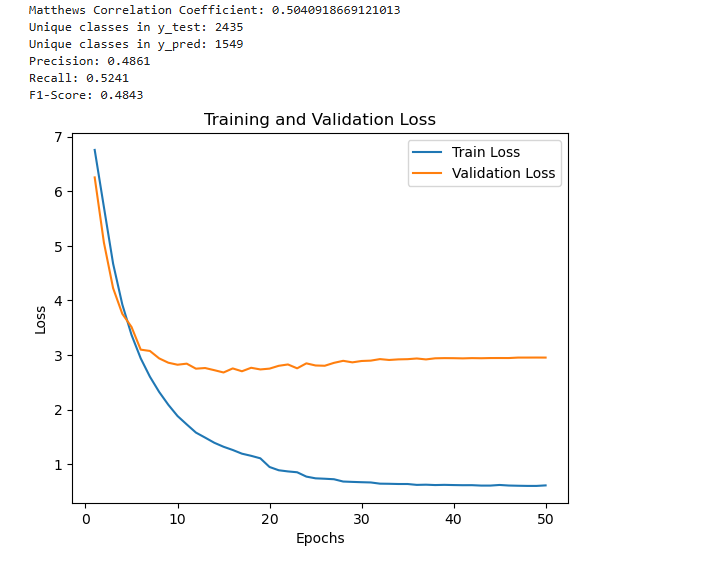

Batch: 64
100 epochs
with additional pooling layers after each convolutional layer



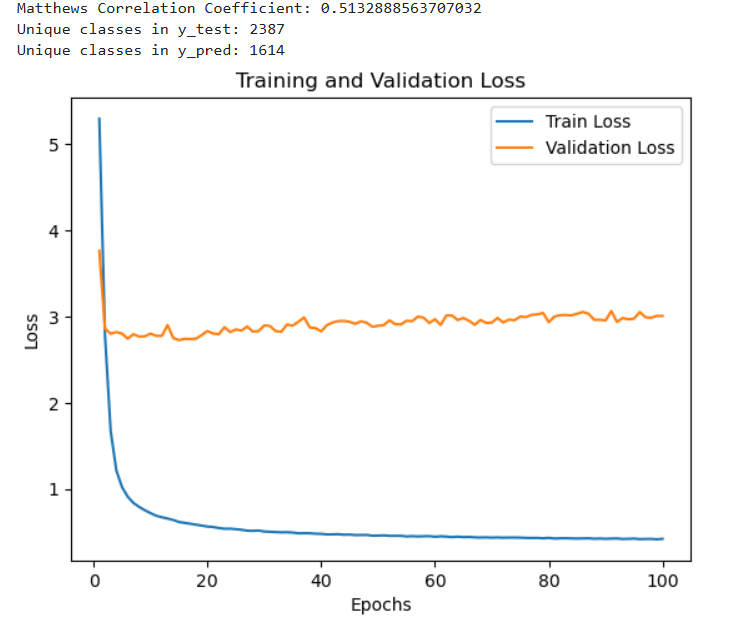

![](scheduler.png)

### Interpretation & Discussion

The training losses decrease steadily and reach very low value, showing that the models have high capacity to fit the training data quickly. This was expected due to the complex number of layers (4 convolutional + 1 fully connected).

#### Models using sequences with length 256:




The validation losses of each model increase around epoch 10–15, suggesting, that the models were overfitted: they were memorizing the training data instead of learning patterns.

There are also large gaps between the training losses and validation losses, that can suggest overfitting as well.

Matthews Correlation Coefficients of these models (= 0.5) are significantly better than from the previous week (last week: 0.0 for logistical regression and 0.0067 for random forest). That means, that the models capture meaningful patterns, but their predictions are far from perfect. This may be due to the class imbalance, as some classes might have very few samples in the training set, and the models may focus on predicting the majority classes, neglecting minority ones. Of course, overfitting of the models and their capacity could influence the MCCs as well.

The difference between the number of unique classes in y_test and y_pred suggests that the models are not predicting all the classes present in the test set, that can also be the case due to the class imbalance.

It is worth mentioning, that different number of epochs delivered almost the same results in connection with training evaluation.

#### Models using sequences with length 409:

Validation loss is decreasing in the beginning, but from 10th epoch stays constant. Model with dropout and learning rate scheduler deliver almost the same results as without these adjustments, indicating that the cause of overfitting can be elsewhere.

MCCs and number of unique classes are almost as same as from the models of sequences with the length of 256 AA, suggesting that the problem of the class imbalance is still the case.

In conclusion the CNN approach has to be adjusted further, to be able to get precise results.

#### Possible issues and next steps:

##### Handle overfitting issue

----- too much data? padding problems? different optimizers?------

##### Adjust model complexity

The model may have too many layers -> further experiments with less complexity required, for example with only one layer

##### Handle class imbalance issue

Possibly another embedding approach is needed.